In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/processed/cleaned_master_dataset.csv")

df["date"] = pd.to_datetime(df["date"])

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


C:\Users\user\AppData\Local\Temp\ipykernel_4416\1960261401.py:1: DtypeWarning: Columns (0: promo_event) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_master_dataset.csv")


In [3]:
df.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,list_price,week,month,season,is_holiday,promo_event,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2024-01-01,SKU001,16,3814.08,238.38,0,Appliances,General,2023-01-01,173,238.38,1,1,Winter,0,NaN,171.0,95.0,13.0,71.0
1,2024-01-01,SKU002,9,943.65,104.85,0,Furniture,General,2023-01-01,72,104.85,1,1,Winter,0,NaN,78.0,59.0,5.0,29.0
2,2024-01-01,SKU003,14,4658.92,332.78,0,Furniture,General,2023-01-01,183,332.78,1,1,Winter,0,NaN,135.0,86.0,15.0,74.0
3,2024-01-01,SKU004,11,2825.35,256.85,0,Furniture,General,2023-01-01,161,256.85,1,1,Winter,0,NaN,207.0,11.0,15.0,20.0
4,2024-01-01,SKU005,12,575.40,47.95,0,Furniture,General,2023-01-01,33,47.95,1,1,Winter,0,NaN,155.0,68.0,6.0,49.0


In [4]:
print(df.shape)

df.info()

df.describe()

(73000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 73000 entries, 0 to 72999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            73000 non-null  datetime64[us]
 1   sku_id          73000 non-null  str           
 2   units_sold      73000 non-null  int64         
 3   revenue         73000 non-null  float64       
 4   unit_price      73000 non-null  float64       
 5   promo_flag      73000 non-null  int64         
 6   category        73000 non-null  str           
 7   subcategory     73000 non-null  str           
 8   launch_date     73000 non-null  str           
 9   unit_cost       73000 non-null  int64         
 10  list_price      73000 non-null  float64       
 11  week            73000 non-null  int64         
 12  month           73000 non-null  int64         
 13  season          73000 non-null  str           
 14  is_holiday      73000 non-null  int64         
 15  p

,date,units_sold,revenue,unit_price,promo_flag,unit_cost,list_price,week,month,is_holiday,on_hand_units,on_order_units,lead_time_days,reorder_point
count,73000,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,9600.000000,9600.000000,9600.000000,9600.000000
mean,2024-07-01 00:00:00,11.901219,2078.379005,175.070134,0.079918,107.645000,176.484950,26.430137,6.498630,0.142466,158.729375,49.728437,11.956250,49.877292
min,2024-01-01 00:00:00,0.000000,0.000000,14.980000,0.000000,10.000000,16.640000,1.000000,1.000000,0.000000,20.000000,0.000000,3.000000,20.000000
25%,2024-04-01 00:00:00,9.000000,951.800000,94.060000,0.000000,57.750000,94.780000,13.000000,4.000000,0.000000,87.000000,24.000000,7.000000,35.000000
50%,2024-07-01 00:00:00,12.000000,1799.560000,166.710000,0.000000,107.000000,167.980000,26.000000,7.000000,0.000000,159.000000,50.000000,12.000000,50.000000
75%,2024-09-30 00:00:00,15.000000,2961.340000,248.890000,0.000000,160.250000,253.352500,39.000000,9.000000,0.000000,229.000000,75.000000,17.000000,65.000000
max,2024-12-30 00:00:00,32.000000,10292.400000,381.200000,1.000000,200.000000,381.200000,52.000000,12.000000,1.000000,300.000000,100.000000,21.000000,80.000000
std,NaN,4.226451,1398.413197,95.518430,0.271168,56.160593,96.137679,15.047013,3.443998,0.349530,81.126128,29.136575,5.489628,17.712634


In [5]:
print("Total Units Sold:", df["units_sold"].sum())

Total Units Sold: 868789


In [6]:
print("Average Units Sold:", df["units_sold"].mean())

Average Units Sold: 11.901219178082192


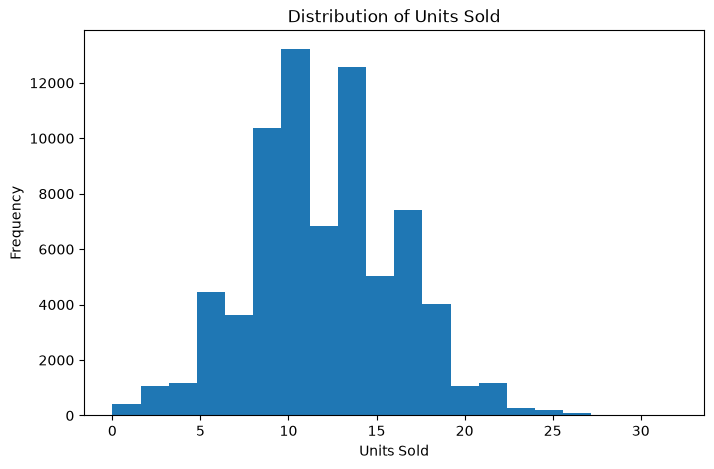

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["units_sold"], bins=20)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

In [8]:
print(df["revenue"].sum())

151721667.32999998


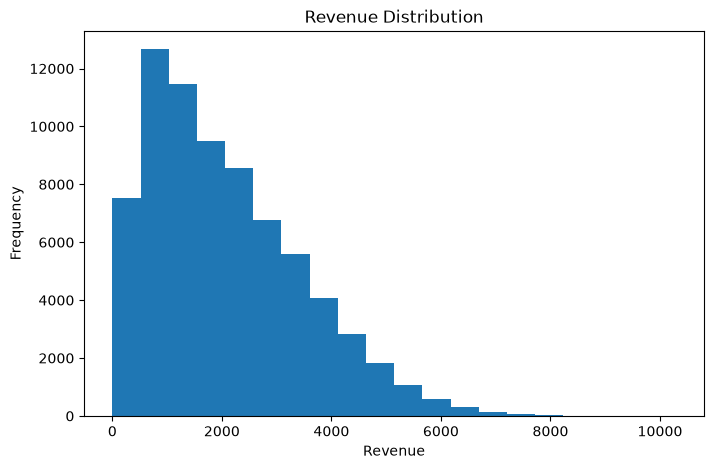

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["revenue"], bins=20)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [10]:
monthly_sales = df.groupby("month")["units_sold"].sum()

print(monthly_sales)

month
1     73649
2     69215
3     73713
4     71915
5     73878
6     71022
7     74107
8     73485
9     71356
10    73258
11    71720
12    71471
Name: units_sold, dtype: int64


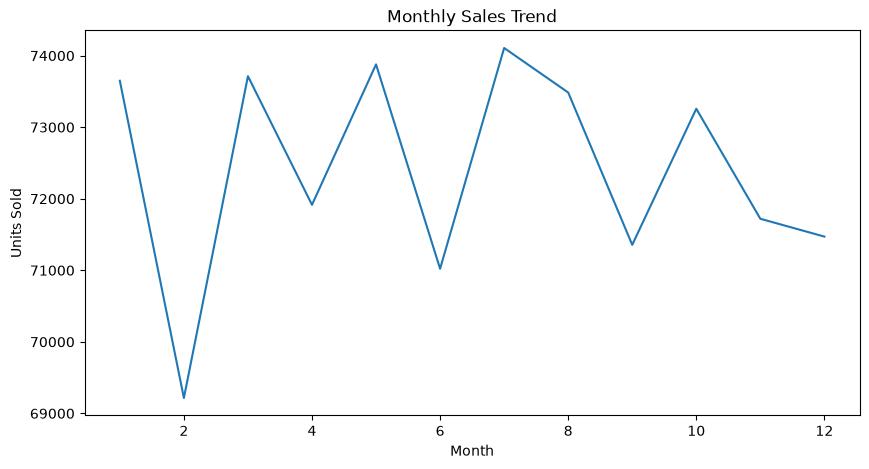

In [11]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.show()

In [12]:
season_sales = df.groupby("season")["units_sold"].sum()

print(season_sales)

season
Autumn    216334
Spring    219506
Summer    218614
Winter    214335
Name: units_sold, dtype: int64


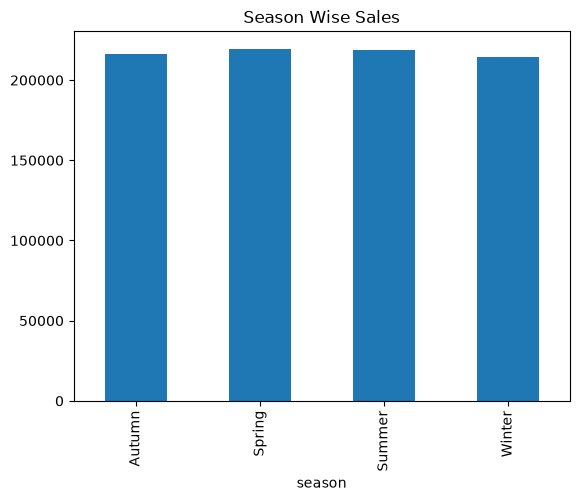

In [13]:
season_sales.plot(kind="bar")

plt.title("Season Wise Sales")

plt.show()

In [14]:
holiday_sales = df.groupby("is_holiday")["units_sold"].mean()

print(holiday_sales)

is_holiday
0    11.887412
1    11.984327
Name: units_sold, dtype: float64


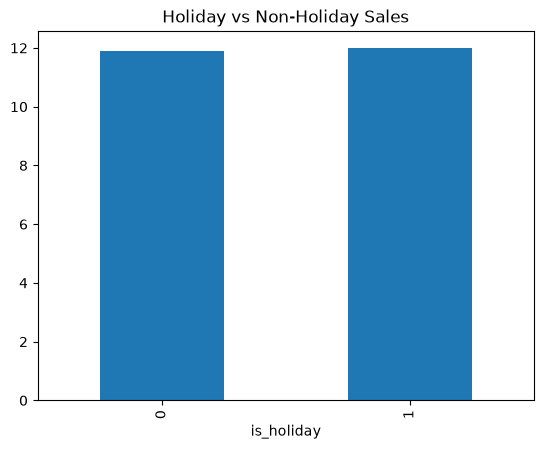

In [15]:
holiday_sales.plot(kind="bar")

plt.title("Holiday vs Non-Holiday Sales")

plt.show()

In [16]:
promo_sales = df.groupby("promo_flag")["units_sold"].mean()

print(promo_sales)

promo_flag
0    11.496576
1    16.559822
Name: units_sold, dtype: float64


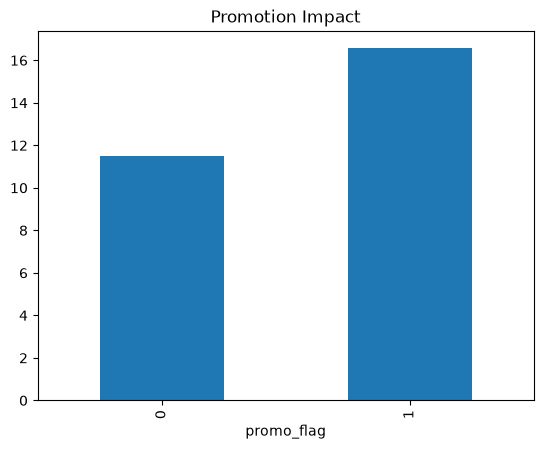

In [17]:
promo_sales.plot(kind="bar")

plt.title("Promotion Impact")

plt.show()

In [18]:
inventory = df.groupby("category")["on_hand_units"].mean()

print(inventory)

category
Appliances    160.373299
Decor         157.407853
Furniture     157.875000
Kitchen       159.528409
Name: on_hand_units, dtype: float64


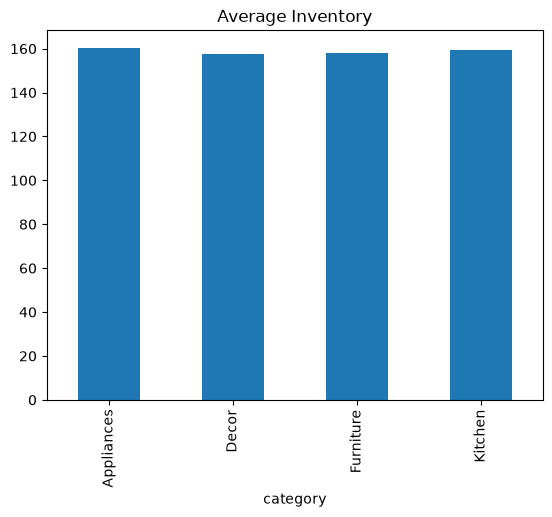

In [19]:
inventory.plot(kind="bar")

plt.title("Average Inventory")

plt.show()

In [20]:
corr = df[[
    "units_sold",
    "revenue",
    "unit_price",
    "on_hand_units"
]].corr()

print(corr)

               units_sold   revenue  unit_price  on_hand_units
units_sold       1.000000  0.514069   -0.012802      -0.011039
revenue          0.514069  1.000000    0.802237      -0.001668
unit_price      -0.012802  0.802237    1.000000       0.004878
on_hand_units   -0.011039 -0.001668    0.004878       1.000000


# EDA Findings

1. Highest selling category:
2. Lowest selling category:
3. Best month:
4. Lowest month:
5. Best season:
6. Promotion impact:
7. Holiday impact:
8. Inventory observations:
9. Revenue insights:
10. Key recommendations: